In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# d = 0.0, т.к. система консервативная
w = 10
g = 0.1

q = 1 # 2,3
p = 0

def sys(t, y):
    q, p = y
    dqdt = p
    dpdt = -w**2*(q + g*q**3)
    return [dqdt, dpdt]

In [26]:
init_cond = [q, p]                                # начальные условия из дано
t_span = (0, 5)                                   # рассматриваем временной промежуток от 0 до 10
points = np.linspace(t_span[0], t_span[1], 1000)  # точки для оценки, они же time points

solution = solve_ivp(sys, t_span, init_cond, t_eval=points)
t_values = solution.t
q_values = solution.y[0]
p_values = solution.y[1]

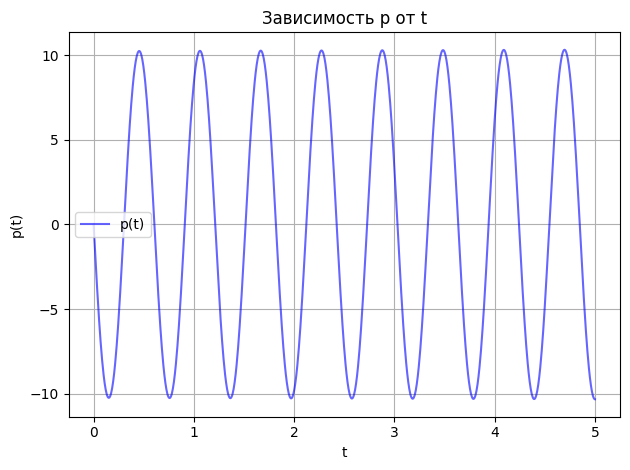

In [27]:
# График p(t)
plt.plot(t_values, p_values, label='p(t)', color='b', alpha=0.6)
plt.title('Зависимость p от t')
plt.xlabel('t')
plt.ylabel('p(t)')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

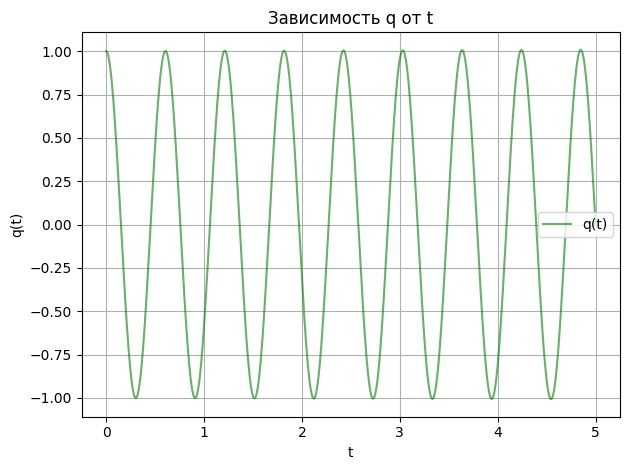

In [28]:
# График q(t)
plt.plot(t_values, q_values, label='q(t)', color='g', alpha=0.6)
plt.title('Зависимость q от t')
plt.xlabel('t')
plt.ylabel('q(t)')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

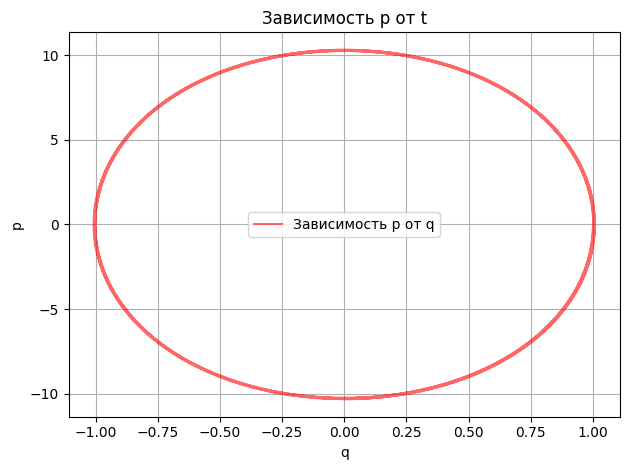

In [29]:
plt.plot(q_values, p_values, label='Зависимость p от q', color='r', alpha=0.6)
plt.title('Зависимость p от t')
plt.xlabel('q')
plt.ylabel('p')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

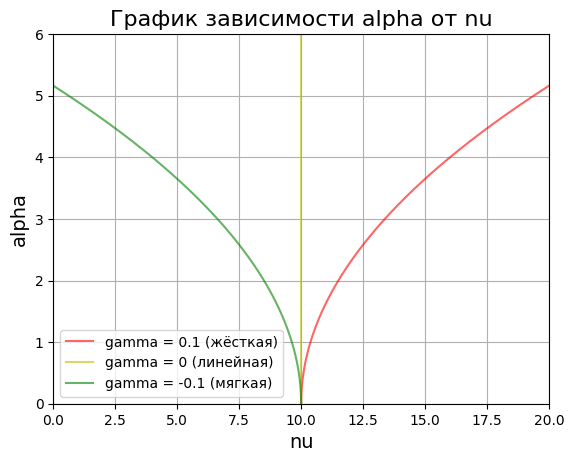

In [30]:
# Теперь займёмся скелетными кривыми...

# nu = w(1 + (3/8)*g*a^2)

a_v = np.linspace(0, 10, 400)  # От -10 до 10 с 400 точками

# Вычисление значений nu
nu_v01 = w * (1 + (3/8)*0.1*a_v**2)
nu_v0 = w * (1 + (3/8)*0*a_v**2)
nu_v_01 = w * (1 + (3/8)*(-0.1)*a_v**2)

# Построение графика
plt.plot(nu_v01, a_v, label='gamma = 0.1 (жёсткая)', color='r', alpha = 0.6)
plt.plot(nu_v0, a_v, label='gamma = 0 (линейная)', color='y', alpha = 0.6)
plt.plot(nu_v_01, a_v, label='gamma = -0.1 (мягкая)', color='g', alpha = 0.6)
plt.xlabel('nu', fontsize=14)
plt.ylabel('alpha', fontsize=14)
plt.xlim(0, 20)
plt.ylim(0, 6)
plt.title('График зависимости alpha от nu', fontsize=16)
plt.grid()
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.legend()
plt.show()